# ML Pipeline Improvements

Extends notebook 15 with two improvements:
1. Report training metrics alongside test metrics (distinguish no-signal vs overfitting)
2. Recursive Feature Elimination (RFECV) with nested CV to find optimal feature subset

Reads from existing CSVs. No dependency on new images.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import make_scorer, recall_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

print("Imports OK")

Imports OK


In [2]:
# load data
df = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]

print(f"Samples: {len(df)}, Features: {len(feature_cols)}")
print(f"Class balance: {(df['rejection'] == 0).sum()} no-rej, {(df['rejection'] == 1).sum()} rej")

Samples: 134, Features: 93
Class balance: 95 no-rej, 39 rej


## Step 1: Remove correlated features

Same approach as NB 15: drop one from each pair with |r| > 0.9, keeping the one
with the lower p-value from the statistical analysis.

In [3]:
def remove_correlated_features(data, features, threshold, stats_path):
    """Drop features that are highly correlated, keeping the one with lower p-value."""
    p_values = {}
    if os.path.exists(stats_path):
        stats_df = pd.read_csv(stats_path)
        p_values = dict(zip(stats_df["feature"], stats_df["p_value"]))

    corr = data[features].corr().abs()
    to_drop = set()

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if corr.iloc[i, j] > threshold:
                feat_i = features[i]
                feat_j = features[j]
                if feat_i in to_drop or feat_j in to_drop:
                    continue
                p_i = p_values.get(feat_i, 1.0)
                p_j = p_values.get(feat_j, 1.0)
                if p_i <= p_j:
                    to_drop.add(feat_j)
                else:
                    to_drop.add(feat_i)

    remaining = [f for f in features if f not in to_drop]
    return remaining, to_drop


stats_path = os.path.join("reports", "14a_stats_radiomics_features.csv")
reduced_features, dropped = remove_correlated_features(
    df, feature_cols, threshold=0.9, stats_path=stats_path
)
print(f"Original: {len(feature_cols)}, Dropped: {len(dropped)}, Remaining: {len(reduced_features)}")

Original: 93, Dropped: 62, Remaining: 31


## Step 2: Classification with train + test metrics

Same models as NB 15, but now we also report training AUC.
This tells us whether the model learned nothing (train ~0.5) or overfit (train high, test ~0.5).

In [4]:
def evaluate_with_train_metrics(X, y, label):
    """Run stratified 5-fold CV and report both train and test metrics."""
    print(f"\n--- {label} ---")
    print(f"Samples: {len(y)}, Features: {X.shape[1]}")
    print(f"Class balance: {(y == 0).sum()} no-rej, {(y == 1).sum()} rej")

    if (y == 1).sum() < 5 or (y == 0).sum() < 5:
        print("Too few samples in one class. Skipping.")
        return None

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {
        "auc": "roc_auc",
        "sensitivity": make_scorer(recall_score, pos_label=1),
        "specificity": make_scorer(recall_score, pos_label=0),
    }

    models = {
        "LogReg_L2": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=1.0, penalty="l2", class_weight="balanced",
                max_iter=1000, random_state=42)),
        ]),
        "RandomForest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=100, class_weight="balanced",
                random_state=42)),
        ]),
    }

    all_results = []
    for name, model in models.items():
        cv_results = cross_validate(
            model, X, y, cv=cv, scoring=scoring,
            return_train_score=True
        )

        result = {
            "dataset": label,
            "model": name,
            "train_auc": round(cv_results["train_auc"].mean(), 3),
            "train_auc_std": round(cv_results["train_auc"].std(), 3),
            "test_auc": round(cv_results["test_auc"].mean(), 3),
            "test_auc_std": round(cv_results["test_auc"].std(), 3),
            "test_sensitivity": round(cv_results["test_sensitivity"].mean(), 3),
            "test_specificity": round(cv_results["test_specificity"].mean(), 3),
        }
        all_results.append(result)

        print(f"  {name}:")
        print(f"    Train AUC = {result['train_auc']:.3f} (+/-{result['train_auc_std']:.3f})")
        print(f"    Test  AUC = {result['test_auc']:.3f} (+/-{result['test_auc_std']:.3f})")
        print(f"    Test  Sens={result['test_sensitivity']:.3f}, Spec={result['test_specificity']:.3f}")

    return all_results

In [5]:
# full dataset
X_full = df[reduced_features].values
y_full = df["rejection"].values

results_full = evaluate_with_train_metrics(X_full, y_full, "Full dataset")


--- Full dataset ---
Samples: 134, Features: 31
Class balance: 95 no-rej, 39 rej
  LogReg_L2:
    Train AUC = 0.772 (+/-0.035)
    Test  AUC = 0.429 (+/-0.071)
    Test  Sens=0.407, Spec=0.442
  RandomForest:
    Train AUC = 1.000 (+/-0.000)
    Test  AUC = 0.515 (+/-0.105)
    Test  Sens=0.100, Spec=0.958


In [6]:
# late subset (motivo 3, 4, 5 = beyond ~90 days post-transplant)
late = df[df["motivo"].isin([3, 4, 5])]
X_late = late[reduced_features].values
y_late = late["rejection"].values

results_late = evaluate_with_train_metrics(X_late, y_late, f"Late subset (N={len(late)})")


--- Late subset (N=68) ---
Samples: 68, Features: 31
Class balance: 39 no-rej, 29 rej
  LogReg_L2:
    Train AUC = 0.853 (+/-0.005)
    Test  AUC = 0.515 (+/-0.095)
    Test  Sens=0.580, Spec=0.543
  RandomForest:
    Train AUC = 1.000 (+/-0.000)
    Test  AUC = 0.497 (+/-0.046)
    Test  Sens=0.373, Spec=0.775


### Train vs Test AUC visualization

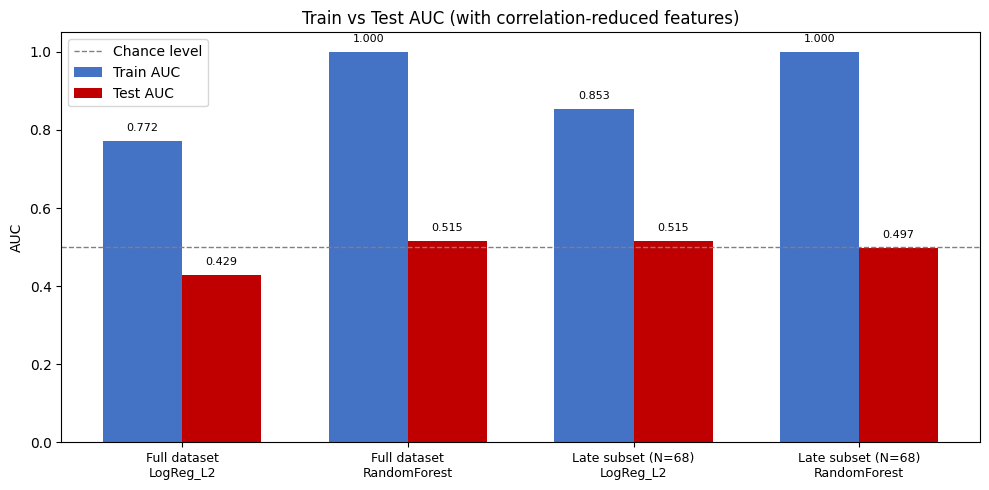

In [7]:
all_baseline = results_full + results_late
baseline_df = pd.DataFrame(all_baseline)

fig, ax = plt.subplots(figsize=(10, 5))

labels = []
train_aucs = []
test_aucs = []
for _, row in baseline_df.iterrows():
    labels.append(f"{row['dataset']}\n{row['model']}")
    train_aucs.append(row["train_auc"])
    test_aucs.append(row["test_auc"])

x = np.arange(len(labels))
width = 0.35

bars_train = ax.bar(x - width/2, train_aucs, width, label="Train AUC", color="#4472C4")
bars_test = ax.bar(x + width/2, test_aucs, width, label="Test AUC", color="#C00000")

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.set_ylabel("AUC")
ax.set_title("Train vs Test AUC (with correlation-reduced features)")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend()

# value labels on bars
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Step 3: Recursive Feature Elimination (nested CV)

We have 31 features after correlation removal. RFE asks: is there a smaller subset
that actually works better?

**How RFE works:**
1. Train a model (e.g., LogReg) on all 31 features
2. Check which feature the model considers least important (smallest absolute coefficient)
3. Drop that one feature
4. Train again on 30 features, drop the least important, train on 29, drop... all the way down to 1
5. At each step, measure AUC using a small inner cross-validation (3-fold)
6. Pick the number of features that gave the best inner AUC

**Why nested CV (two loops):**
- Outer loop (5 folds): splits data into train/test. The test fold is for final evaluation only —
  it is never touched during feature selection.
- Inner loop (3 folds, inside RFECV): happens only on the training portion. This is where RFE
  tries different numbers of features and picks the best.

So in each outer fold, RFE independently decides how many features to keep. If the feature
selection is stable, each fold should pick roughly the same number and the same features.
If it picks wildly different numbers per fold (e.g., 1 in one fold, 25 in another),
that itself is evidence there is no stable signal.

After RFE selects features on the training fold, we train a fresh model on just those features
and evaluate on the held-out test fold. This way there is no data leakage — the test data
never influenced which features were selected.

In [8]:
def run_nested_rfe(X, y, feature_names, label, estimator_name="LogReg"):
    """Run RFECV inside nested CV. Returns per-fold results."""
    print(f"\n--- RFE ({estimator_name}) on {label} ---")
    print(f"Samples: {len(y)}, Starting features: {X.shape[1]}")

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    fold_results = []
    feature_selection_counts = {f: 0 for f in feature_names}

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        # scale on training fold only
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # choose estimator for RFE
        if estimator_name == "LogReg":
            est = LogisticRegression(
                C=1.0, penalty="l2", class_weight="balanced",
                max_iter=1000, random_state=42
            )
        else:
            est = RandomForestClassifier(
                n_estimators=100, class_weight="balanced",
                random_state=42
            )

        # RFE on training fold
        rfecv = RFECV(
            estimator=est,
            step=1,
            cv=inner_cv,
            scoring="roc_auc",
            min_features_to_select=1,
        )
        rfecv.fit(X_train_scaled, y_train)

        # which features were selected this fold
        selected = []
        for feat, was_selected in zip(feature_names, rfecv.support_):
            if was_selected:
                selected.append(feat)
                feature_selection_counts[feat] += 1

        # evaluate on test fold with selected features
        X_train_sel = rfecv.transform(X_train_scaled)
        X_test_sel = rfecv.transform(X_test_scaled)

        # train fresh model on selected features
        if estimator_name == "LogReg":
            final_model = LogisticRegression(
                C=1.0, penalty="l2", class_weight="balanced",
                max_iter=1000, random_state=42
            )
        else:
            final_model = RandomForestClassifier(
                n_estimators=100, class_weight="balanced",
                random_state=42
            )
        final_model.fit(X_train_sel, y_train)

        # train AUC
        y_train_prob = final_model.predict_proba(X_train_sel)[:, 1]
        train_auc = roc_auc_score(y_train, y_train_prob)

        # test AUC
        y_test_prob = final_model.predict_proba(X_test_sel)[:, 1]
        test_auc = roc_auc_score(y_test, y_test_prob)

        fold_results.append({
            "fold": fold_idx,
            "n_features": rfecv.n_features_,
            "train_auc": round(train_auc, 3),
            "test_auc": round(test_auc, 3),
            "selected_features": selected,
        })

        print(f"  Fold {fold_idx}: {rfecv.n_features_} features, "
              f"Train AUC={train_auc:.3f}, Test AUC={test_auc:.3f}")

    # summary
    mean_test = np.mean([r["test_auc"] for r in fold_results])
    mean_train = np.mean([r["train_auc"] for r in fold_results])
    print(f"\n  Mean Train AUC: {mean_train:.3f}")
    print(f"  Mean Test AUC:  {mean_test:.3f}")

    return fold_results, feature_selection_counts

In [9]:
# RFE with LogReg on full dataset
X_full = df[reduced_features].values
y_full = df["rejection"].values

rfe_lr_full, rfe_lr_full_counts = run_nested_rfe(
    X_full, y_full, reduced_features, "Full dataset", "LogReg"
)


--- RFE (LogReg) on Full dataset ---
Samples: 134, Starting features: 31
  Fold 0: 11 features, Train AUC=0.772, Test AUC=0.368
  Fold 1: 1 features, Train AUC=0.560, Test AUC=0.526
  Fold 2: 5 features, Train AUC=0.706, Test AUC=0.368
  Fold 3: 1 features, Train AUC=0.551, Test AUC=0.533
  Fold 4: 6 features, Train AUC=0.678, Test AUC=0.556

  Mean Train AUC: 0.653
  Mean Test AUC:  0.470


In [10]:
# RFE with Random Forest on full dataset
rfe_rf_full, rfe_rf_full_counts = run_nested_rfe(
    X_full, y_full, reduced_features, "Full dataset", "RandomForest"
)


--- RFE (RandomForest) on Full dataset ---
Samples: 134, Starting features: 31
  Fold 0: 2 features, Train AUC=1.000, Test AUC=0.418
  Fold 1: 15 features, Train AUC=1.000, Test AUC=0.576
  Fold 2: 1 features, Train AUC=1.000, Test AUC=0.674
  Fold 3: 21 features, Train AUC=1.000, Test AUC=0.444
  Fold 4: 14 features, Train AUC=1.000, Test AUC=0.515

  Mean Train AUC: 1.000
  Mean Test AUC:  0.525


In [11]:
# RFE with LogReg on late subset
late = df[df["motivo"].isin([3, 4, 5])]
X_late = late[reduced_features].values
y_late = late["rejection"].values

rfe_lr_late, rfe_lr_late_counts = run_nested_rfe(
    X_late, y_late, reduced_features, f"Late subset (N={len(late)})", "LogReg"
)


--- RFE (LogReg) on Late subset (N=68) ---
Samples: 68, Starting features: 31
  Fold 0: 1 features, Train AUC=0.634, Test AUC=0.146
  Fold 1: 25 features, Train AUC=0.854, Test AUC=0.500
  Fold 2: 13 features, Train AUC=0.837, Test AUC=0.521
  Fold 3: 7 features, Train AUC=0.777, Test AUC=0.762
  Fold 4: 1 features, Train AUC=0.613, Test AUC=0.425

  Mean Train AUC: 0.743
  Mean Test AUC:  0.471


In [12]:
# RFE with Random Forest on late subset
rfe_rf_late, rfe_rf_late_counts = run_nested_rfe(
    X_late, y_late, reduced_features, f"Late subset (N={len(late)})", "RandomForest"
)


--- RFE (RandomForest) on Late subset (N=68) ---
Samples: 68, Starting features: 31
  Fold 0: 7 features, Train AUC=1.000, Test AUC=0.417
  Fold 1: 1 features, Train AUC=1.000, Test AUC=0.750
  Fold 2: 4 features, Train AUC=1.000, Test AUC=0.552
  Fold 3: 4 features, Train AUC=1.000, Test AUC=0.750
  Fold 4: 1 features, Train AUC=1.000, Test AUC=0.338

  Mean Train AUC: 1.000
  Mean Test AUC:  0.561


### Feature selection frequency

Which features were selected most often across the 5 outer folds?
A feature selected 5/5 times is consistently useful; 1/5 is unstable.

In [13]:
# combine LogReg counts (full + late = 10 folds total)
combined_lr_counts = {}
for feat in reduced_features:
    combined_lr_counts[feat] = rfe_lr_full_counts[feat] + rfe_lr_late_counts[feat]

lr_ranking = pd.DataFrame({
    "feature": list(combined_lr_counts.keys()),
    "times_selected_full": [rfe_lr_full_counts[f] for f in combined_lr_counts],
    "times_selected_late": [rfe_lr_late_counts[f] for f in combined_lr_counts],
    "times_selected_total": list(combined_lr_counts.values()),
}).sort_values("times_selected_total", ascending=False)

print("LogReg RFE - Feature selection frequency (out of 5 folds each):")
print(lr_ranking.head(15).to_string(index=False))

LogReg RFE - Feature selection frequency (out of 5 folds each):
                                     feature  times_selected_full  times_selected_late  times_selected_total
                          original_glcm_Imc2                    4                    3                     7
                     original_ngtdm_Strength                    1                    4                     5
                   original_ngtdm_Complexity                    3                    2                     5
                   original_ngtdm_Coarseness                    3                    2                     5
 original_glrlm_ShortRunLowGrayLevelEmphasis                    1                    4                     5
                     original_ngtdm_Contrast                    1                    3                     4
             original_glrlm_ShortRunEmphasis                    0                    3                     3
                   original_glrlm_RunEntropy                    

In [14]:
# same for Random Forest
combined_rf_counts = {}
for feat in reduced_features:
    combined_rf_counts[feat] = rfe_rf_full_counts[feat] + rfe_rf_late_counts[feat]

rf_ranking = pd.DataFrame({
    "feature": list(combined_rf_counts.keys()),
    "times_selected_full": [rfe_rf_full_counts[f] for f in combined_rf_counts],
    "times_selected_late": [rfe_rf_late_counts[f] for f in combined_rf_counts],
    "times_selected_total": list(combined_rf_counts.values()),
}).sort_values("times_selected_total", ascending=False)

print("Random Forest RFE - Feature selection frequency (out of 5 folds each):")
print(rf_ranking.head(15).to_string(index=False))

Random Forest RFE - Feature selection frequency (out of 5 folds each):
                               feature  times_selected_full  times_selected_late  times_selected_total
               original_ngtdm_Contrast                    4                    3                     7
 original_glrlm_RunLengthNonUniformity                    3                    3                     6
                    original_glcm_Imc2                    4                    1                     5
           original_firstorder_Minimum                    3                    1                     4
             original_ngtdm_Complexity                    3                    1                     4
   original_firstorder_RootMeanSquared                    3                    1                     4
       original_glrlm_ShortRunEmphasis                    2                    2                     4
             original_ngtdm_Coarseness                    3                    1                     4
  

### RFE results visualization

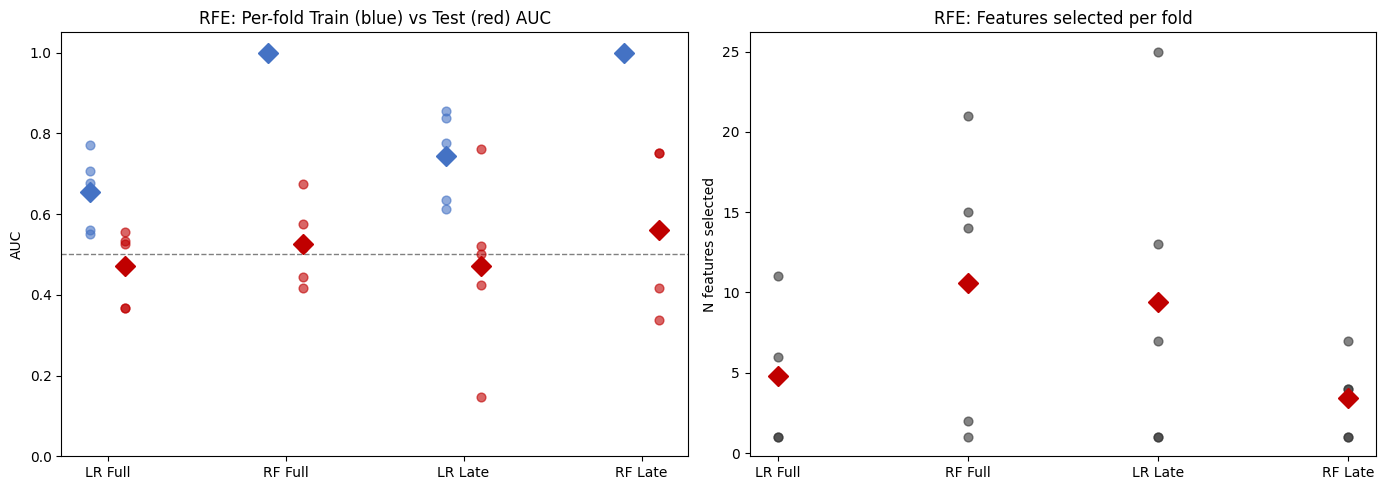

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-fold AUC for all RFE experiments
ax = axes[0]
experiments = [
    ("LR Full", rfe_lr_full),
    ("RF Full", rfe_rf_full),
    ("LR Late", rfe_lr_late),
    ("RF Late", rfe_rf_late),
]

x_positions = np.arange(len(experiments))
for i, (exp_name, fold_results) in enumerate(experiments):
    test_aucs = [r["test_auc"] for r in fold_results]
    train_aucs = [r["train_auc"] for r in fold_results]
    ax.scatter([i - 0.1] * len(train_aucs), train_aucs,
              color="#4472C4", alpha=0.6, s=40, zorder=3)
    ax.scatter([i + 0.1] * len(test_aucs), test_aucs,
              color="#C00000", alpha=0.6, s=40, zorder=3)
    ax.plot(i - 0.1, np.mean(train_aucs), "D",
            color="#4472C4", markersize=10, zorder=4)
    ax.plot(i + 0.1, np.mean(test_aucs), "D",
            color="#C00000", markersize=10, zorder=4)

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([e[0] for e in experiments])
ax.set_ylabel("AUC")
ax.set_title("RFE: Per-fold Train (blue) vs Test (red) AUC")
ax.set_ylim(0, 1.05)

# Right: number of features selected per fold
ax = axes[1]
for i, (exp_name, fold_results) in enumerate(experiments):
    n_feats = [r["n_features"] for r in fold_results]
    ax.scatter([i] * len(n_feats), n_feats,
              color="#333333", alpha=0.6, s=40, zorder=3)
    ax.plot(i, np.mean(n_feats), "D",
            color="#C00000", markersize=10, zorder=4)

ax.set_xticks(x_positions)
ax.set_xticklabels([e[0] for e in experiments])
ax.set_ylabel("N features selected")
ax.set_title("RFE: Features selected per fold")

plt.tight_layout()
plt.show()

## Step 4: Summary comparison table

Compare NB 15 baseline (no train metrics, no RFE) with NB 16 results.

In [16]:
# build summary table
summary_rows = []

# baseline results from step 2
for r in all_baseline:
    summary_rows.append({
        "experiment": "Baseline (corr removed)",
        "dataset": r["dataset"],
        "model": r["model"],
        "n_features": len(reduced_features),
        "train_auc": r["train_auc"],
        "test_auc": r["test_auc"],
    })

# RFE results
rfe_experiments = [
    ("Full dataset", "LogReg", rfe_lr_full),
    ("Full dataset", "RandomForest", rfe_rf_full),
    (f"Late subset (N={len(late)})", "LogReg", rfe_lr_late),
    (f"Late subset (N={len(late)})", "RandomForest", rfe_rf_late),
]

for dataset_name, model_name, fold_results in rfe_experiments:
    mean_n = np.mean([r["n_features"] for r in fold_results])
    mean_train = np.mean([r["train_auc"] for r in fold_results])
    mean_test = np.mean([r["test_auc"] for r in fold_results])
    model_label = "LogReg_L2" if model_name == "LogReg" else "RandomForest"
    summary_rows.append({
        "experiment": "RFE (nested CV)",
        "dataset": dataset_name,
        "model": model_label,
        "n_features": round(mean_n, 1),
        "train_auc": round(mean_train, 3),
        "test_auc": round(mean_test, 3),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

             experiment            dataset        model  n_features  train_auc  test_auc
Baseline (corr removed)       Full dataset    LogReg_L2        31.0      0.772     0.429
Baseline (corr removed)       Full dataset RandomForest        31.0      1.000     0.515
Baseline (corr removed) Late subset (N=68)    LogReg_L2        31.0      0.853     0.515
Baseline (corr removed) Late subset (N=68) RandomForest        31.0      1.000     0.497
        RFE (nested CV)       Full dataset    LogReg_L2         4.8      0.653     0.470
        RFE (nested CV)       Full dataset RandomForest        10.6      1.000     0.525
        RFE (nested CV) Late subset (N=68)    LogReg_L2         9.4      0.743     0.471
        RFE (nested CV) Late subset (N=68) RandomForest         3.4      1.000     0.561


## Step 5: Save results

In [17]:
# save summary table
summary_path = os.path.join("reports", "16_ml_improved_results.csv")
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary to {summary_path}")

# save feature ranking from LogReg RFE
ranking_path = os.path.join("reports", "16_rfe_feature_ranking_logreg.csv")
lr_ranking.to_csv(ranking_path, index=False)
print(f"Saved LogReg feature ranking to {ranking_path}")

# save feature ranking from RF RFE
ranking_path_rf = os.path.join("reports", "16_rfe_feature_ranking_rf.csv")
rf_ranking.to_csv(ranking_path_rf, index=False)
print(f"Saved RF feature ranking to {ranking_path_rf}")

Saved summary to reports/16_ml_improved_results.csv
Saved LogReg feature ranking to reports/16_rfe_feature_ranking_logreg.csv
Saved RF feature ranking to reports/16_rfe_feature_ranking_rf.csv


## Discussion of Results

### Baseline classification: models overfit to noise

With 31 features (after correlation removal), all test AUCs are around 0.5 (chance level).
But training AUCs are much higher, which tells us what is going on:

- **LogReg** reaches train AUC of 0.772 (full) and 0.853 (late), but test AUC stays at 0.429 and 0.515.
  The ~0.3 gap means LogReg finds patterns in the training data, but those patterns are noise
  that does not generalize to unseen data.

- **Random Forest** reaches train AUC of 1.000 in every case (perfect memorization), while test AUC
  is 0.515 (full) and 0.497 (late). RF memorizes the training set completely but learns nothing
  that transfers. This is textbook overfitting.

The key point: the models are not "failing to learn." They learn plenty. The problem is that
what they learn is spurious — there is no real discriminative signal in these features.

### RFE did not improve classification

Recursive Feature Elimination with nested CV was supposed to find a smaller, better feature subset.
It did not help:

- Test AUCs after RFE range from 0.470 to 0.561, still around chance level.
- The number of features selected is highly inconsistent across folds. For example, LogReg on the
  late subset picked 1 feature in fold 0 but 25 features in fold 1. This instability means there
  is no consistent subset of features that the algorithm can reliably identify as useful.
- RF still reaches train AUC = 1.000 even after RFE, confirming it memorizes regardless of
  how many features are available.

The per-fold variation in test AUC is also very large (e.g., 0.146 to 0.762 for LogReg on late).
With small sample sizes (134 full, 68 late), individual folds can produce high or low AUCs by
chance alone. The means settle back to ~0.5.

### Feature selection is not stable

No feature is selected consistently across all 10 folds (5 full + 5 late). The most frequently
selected feature for LogReg (glcm_Imc2) appears 7/10 times, but most features appear only 2-5 times.

LogReg and Random Forest also disagree on which features matter most. LogReg ranks glcm_Imc2 first;
RF ranks ngtdm_Contrast first. When two different methods cannot agree on which features are
important, it is a strong indicator that neither set of features carries real predictive information.

### What this means

These results confirm and strengthen the negative finding from notebooks 14a and 15:

1. **Standard B-mode radiomics features do not predict pancreas transplant rejection** in this cohort.
2. The negative result is **not caused by poor feature selection** — RFE exhaustively searched
   through feature subsets and found nothing better than chance.
3. The negative result is **not caused by models failing to fit** — both models achieve high
   training performance, they just cannot generalize because the signal is not there.
4. The pipeline itself works correctly (models train, cross-validation runs, feature selection
   operates as expected). The problem is in the data: these texture features do not capture
   differences between rejection and non-rejection ultrasound images.

This is consistent with the statistical analysis in NB 14a, where 0 out of 93 features were
significant after FDR correction (lowest uncorrected p = 0.055 for firstorder_Minimum).